# Demo for Bi-fidelity Stochastic Subspace Descent

We consider the case of adversarial attack with black box model 
$$f(\mathbf{\delta}; y^\dagger, c, g) = \tau\cdot\text{ReLU}(\log[g(\mathbf{\delta}+\mathbf{x}^\dagger)]_{y^\dagger} - \max_{i\neq y^\dagger}\log [g(\mathbf{\delta}+\mathbf{x}^\dagger)]_i) + \lVert \mathbf{\delta}\rVert^2.$$
We set $c = 10.0$, $\mathbf{x}^\dagger, y^\dagger$ as the first test sample, $g(\cdot)$ is a pre-trained CNN with test accuracy $99.02\%$. The low-fidelity model is a SVM returns classification probability with accuracy $98.10\%$.


In [10]:
import numpy as np
from wrapper import *
from mnist import *
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import datasets, transforms
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from joblib import load

# FIX RANDOM SEED
np.random.seed(0)
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load and transform the MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Mean and Std deviation for MNIST
])

# Load CNN model
model_path = './mnist/mnist_cnn_adv.pt'
train_dataset = datasets.MNIST('./mnist', train=True, download=False, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
model = load_or_train_model(model_path, train_loader, device)

tau = 10.0

# Load the model from the file
svm_clf = load('MNIST/svm_clf_mnist.joblib')

def unnormalize(x):
    return (x * 0.3081 + 0.1307) * 255.0

Loading the saved model...


 /Users/nokic/Downloads/BFSSD/mnist.py:114: FutureWarning:You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
 /opt/anaconda3/envs/botorchEnv2/lib/python3.12/site-packages/sklearn/base.py:376: Inc

torch.Size([1, 28, 28]) 7


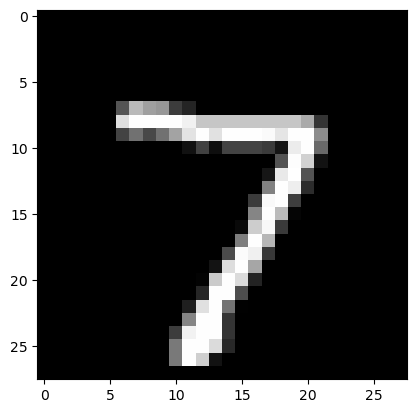

In [34]:
dagger_idx = 0
test_datasets = datasets.MNIST('./mnist', train=False, transform=transform)
x_dagger, y_dagger = test_datasets[dagger_idx]
other_idx = np.setdiff1d(np.arange(10), y_dagger)
plt.imshow(x_dagger.numpy().reshape(28, 28), cmap='gray')
print(x_dagger.shape, y_dagger)

In [35]:
# define the adversarial attack HF function
def f_HF(x):
    """The inputs and outputs are np arrays"""
    x = x.reshape(1, 1, 28, 28)
    x = torch.tensor(x).type(torch.FloatTensor)
    with torch.no_grad():
        y_hat = torch.softmax(model(x + x_dagger.unsqueeze(0)).squeeze(), dim=0)
        log_y_diff = torch.log(y_hat[other_idx].max()) - torch.log(y_hat[y_dagger])
    return -tau * torch.relu(log_y_diff).item() + np.linalg.norm(x) ** 2

In [36]:
def f_LF(x):
    """The inputs and outputs are np arrays"""
    x = x.reshape(1, 784)
    x_0 = unnormalize(x_dagger.reshape(1, 784).detach().numpy())
    y_hat = svm_clf.predict_proba(255.0 * x + x_0).squeeze()
    log_y_diff = np.log(y_hat[other_idx].max()) - np.log(y_hat[y_dagger])
    return -tau * np.max([log_y_diff, 0]) + np.linalg.norm(x) ** 2

In [37]:
obj = objectiveFcn(f_HF,label='kernel')
obj_lowFi= objectiveFcn(f_LF,label='kernel-LF')
obj_alt = objectiveFcn(f_HF,label='kernel-alt')

# initial point
d = 28 * 28
x0 = 1e-4 * np.random.randn(d)
learning_rate = 1e-2
ell = 20
num_iterations = 10
learning_rate_ssd = learning_rate*ell/d
linesearchIter = 10
c = 0.9

In [38]:

num_trials = 1
methods = ['gd', 'cd', 'ssd', 'spsa', 'rgfm', 'ssd_lf', 'ssd_hf', 'ssd_bf', 'ssd_oracle']
res = {m: [] for m in methods}
# gd, cd, ssdd, spsa_ls, rgfm, ssdd_ls, ssdh_ls, ssdd_bt, ssdd_hbt = [], [], [], [], [], [], [], [], []
for i in tqdm(range(num_trials)):
    # Gradient Descent
    _ = grad_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations)
    res['gd'].append(obj.returnHistory())
    # Coordinate Descent
    _ = coor_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations/2)
    res['cd'].append(obj.returnHistory())
    # SSD
    _ = ssd(x0,obj,ell=ell,learning_rate=learning_rate_ssd,num_iterations=num_iterations*d/ell)
    res['ssd'].append(obj.returnHistory())
    # SPSA
    _ = spsa(x0,obj,num_iterations=num_iterations*d)
    res['spsa'].append(obj.returnHistory())
    # Random Gredien-free Minimization
    _ = ssd(x0,obj,ell=1,learning_rate=learning_rate_ssd,num_iterations=num_iterations*d)
    res['rgfm'].append(obj.returnHistory())
    # SSD with linesearch (LF)
    _ = ssd_ls(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_lowFi,
                num_iterations=num_iterations*d/ell, linesearchIter=linesearchIter )
    res['ssd_lf'].append(obj.returnHistory())
    # SSD with linesearch (HF)
    _ = ssd_ls(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_alt,
                num_iterations=num_iterations*d/ell, linesearchIter=linesearchIter )
    res['ssd_oracle'].append(obj.returnHistory())
    # SSD with backtracking linesearch (BF)
    _ = ssd_bt(x0,obj,ell=ell,obj_lowFi= obj_lowFi, c=c,
                num_iterations=num_iterations*d/ell, linesearchIter=linesearchIter )
    res['ssd_bf'].append(obj.returnHistory())
    # SSD with backtracking linesearch (HF)
    _ = ssd_hbt(x0,obj,ell=ell,obj_lowFi= obj_lowFi, c=c,
                num_iterations=num_iterations*d/ell, linesearchIter=linesearchIter )
    res['ssd_hf'].append(obj.returnHistory())


  0%|          | 0/1 [00:00<?, ?it/s]

======== gradient descent ======
======== coordinate descent ========
======== SSD ===================
======== SPSA ===================
======== SSD ===================
======== SSD w/ low-fi linesearch =
======== SSD w/ low-fi linesearch =
======== SSD w/ backtracking bi-fi linesearch =
======== SSD w/ backtracking linesearch =


100%|██████████| 1/1 [02:39<00:00, 159.58s/it]


In [39]:
# Collect data and compute mean/std
T = num_iterations * d
res_mean, res_std = {}, {}
for k, v in res.items():
    res[k] = np.array(v)
    res_mean[k], res_std[k] = np.mean(res[k][:,:T], axis=0), np.std(res[k][:,:T], axis=0)

 <>:24: SyntaxWarning:invalid escape sequence '\e'
 <>:24: SyntaxWarning:invalid escape sequence '\e'
 /var/folders/2h/qpgmp2hn60v7bxdrwgqzjb9r0000gn/T/ipykernel_60104/1960248071.py:24: SyntaxWarning:invalid escape sequence '\e'


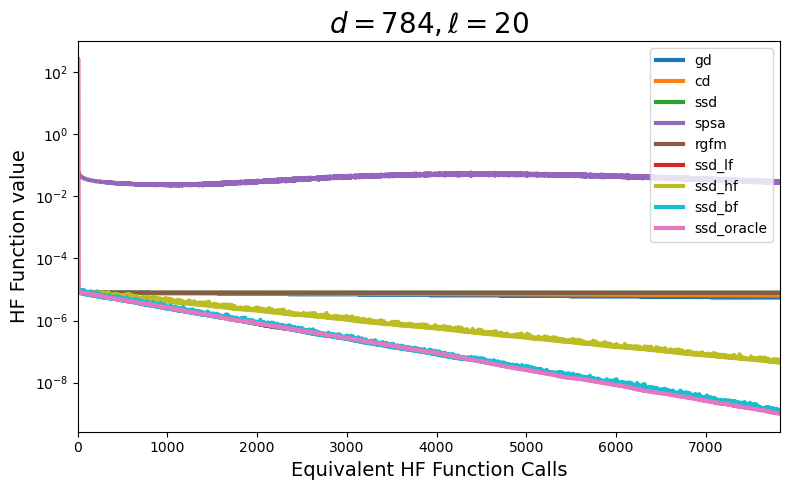

In [40]:
t = np.arange(0, T)
bf_ratio = 1.0#linesearchIter * r2 / ((ell + 1) * r1)
bf_t = (1 + bf_ratio) * t
lw = 3.0
colors = {
    'gd': 'tab:blue',
    'cd': 'tab:orange',
    'ssd': 'tab:green',
    'spsa': 'tab:purple',
    'rgfm': 'tab:brown',
    'ssd_lf': 'tab:red',
    'ssd_hf': 'tab:olive',
    'ssd_bf': 'tab:cyan',
    'ssd_oracle': 'tab:pink'
}

plt.figure(figsize=(8,5))
for k in colors:
    plt.plot(t, res_mean[k], label=k, color=colors[k], lw=lw)
    plt.fill_between(t, res_mean[k]-1.94*res_std[k], res_mean[k]+1.94*res_std[k], alpha=0.2, color=colors[k])
plt.yscale('log')
plt.xlim(0, T - 10)
plt.xlabel('Equivalent HF Function Calls', fontsize=14), plt.ylabel('HF Function value', fontsize=14), plt.legend()
plt.title(f'$d = {d:.0f}, \ell = {ell:.0f}$', fontsize=20)
plt.tight_layout()
# plt.savefig(f'figures-worst/d{d:.0f}-ell{ell:.0f}-rH{r1:.0f}-rL{r2:.0f}.pdf', dpi=200, bbox_inches='tight')

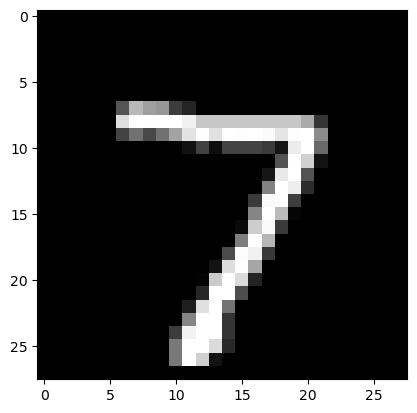

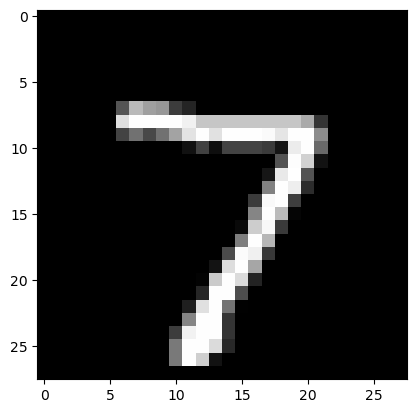

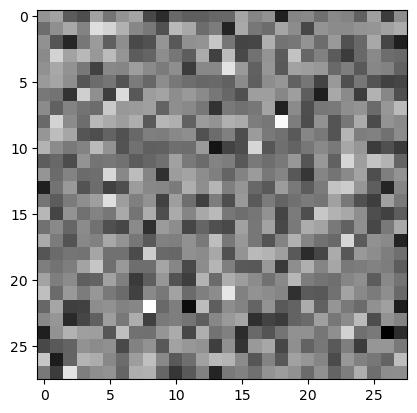

In [41]:
xnew = x_dagger.squeeze().numpy() + 256.0*_.reshape(28, 28)
plt.subplots()
plt.imshow(xnew, cmap='gray')
plt.subplots()
plt.imshow(x_dagger.squeeze().numpy(), cmap='gray')
plt.subplots()
plt.imshow(xnew - x_dagger.squeeze().numpy(), cmap='gray')